In [120]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

In [121]:
# Let's load values from the .env file
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [122]:
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

In [123]:
engine = create_engine(url, echo=False)

In [124]:
my_schema = 'team_1' # update it to your schema

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [125]:
### Let's create a dataframe out of that
df_sleep_health_lifestyle_male = pd.read_sql(sql=text('SELECT * FROM daily_steps_active_male'), con=engine)


In [126]:
df_sleep_health_lifestyle_male

,age_group,active_percentage_ds_10000,active_percentage_ds_9000,active_percentage_ds_8000,active_percentage_ds_7000,active_percentage_ds_6000,active_percentage_ds_5000,active_percentage_ds_4000,active_percentage_ds_3000,active_percentage_ds_2000,active_percentage_ds_1000
0,Adult,0.00,0.00,55.24,57.14,92.38,93.33,96.19,100.0,100.0,100.0
1,Young Adult,2.38,2.38,52.38,53.57,53.57,92.86,94.05,100.0,100.0,100.0


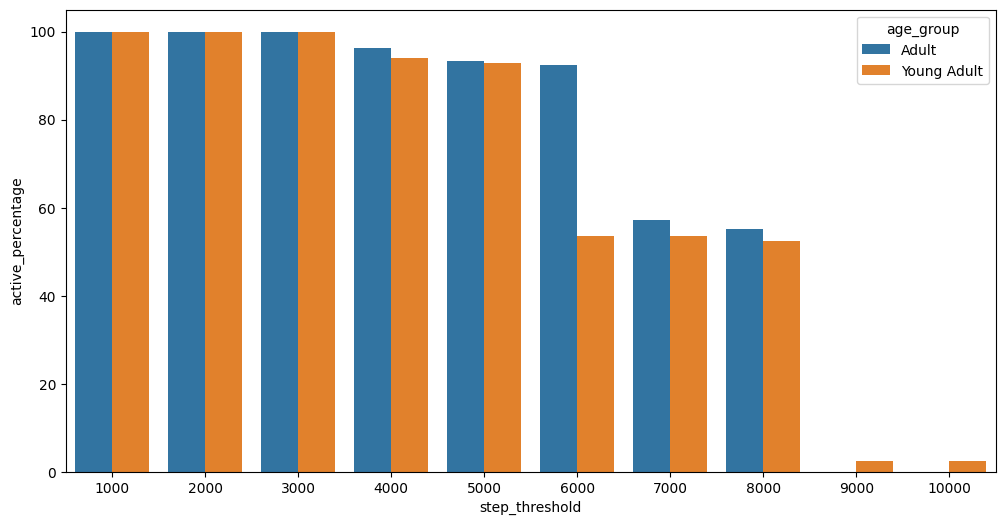

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Umstrukturieren Gruppenbalken
df_sleep_health_lifestyle_male_melted = df_sleep_health_lifestyle_male.melt(id_vars='age_group', var_name='step_threshold', value_name='active_percentage')

#Lesbare Achsenbeschriftung

df_sleep_health_lifestyle_male_melted['step_threshold'] = df_sleep_health_lifestyle_male_melted['step_threshold'].str.extract(r'(\d+)$')[0].astype(int)

#Sortieren nach Schrittanzahl
df_sleep_health_lifestyle_male_melted = df_sleep_health_lifestyle_male_melted.sort_values(by='step_threshold')

plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_melted, x='step_threshold', y='active_percentage', hue='age_group')

plt.show()

#Beide Geschlechter betrachten für Steps per Day -> Female and Male (nicht für Altersgruppe)

In [128]:
df_sleep_health_lifestyle_male_2 = pd.read_sql(sql=text('SELECT * FROM bmi_ageGroup_male'), con=engine)

In [129]:
df_sleep_health_lifestyle_male_2

,age_group,bmi_category,total_people,avg_physical_activity_level,avg_daily_steps
0,Adult,Normal Weight,62,76.24,7919.35
1,Adult,Obese,4,75.00,3600.00
2,Adult,Overweight,39,45.64,5882.05
3,Young Adult,Normal Weight,76,53.55,6815.79
4,Young Adult,Obese,5,38.00,3160.00
5,Young Adult,Overweight,3,40.67,5133.33


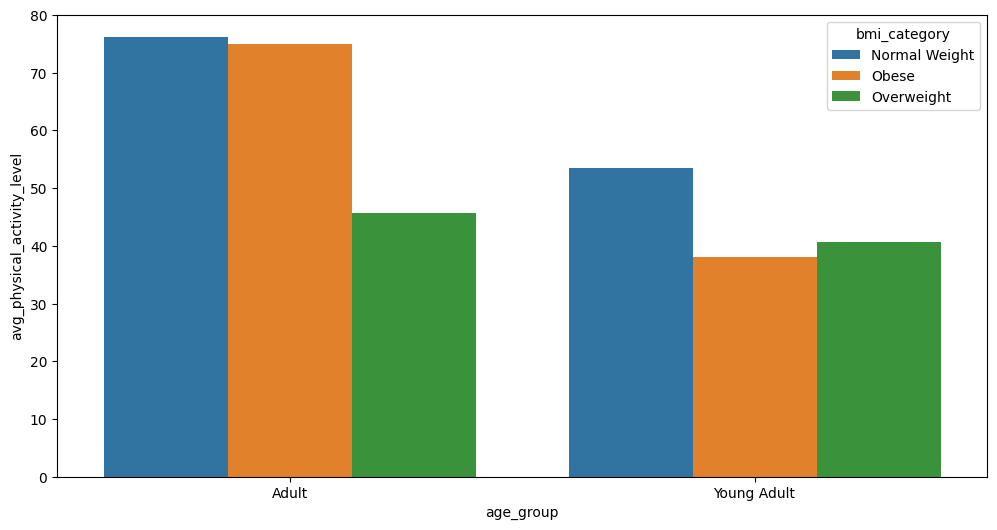

In [130]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_2, x='age_group', y='avg_physical_activity_level', hue='bmi_category')

plt.show()

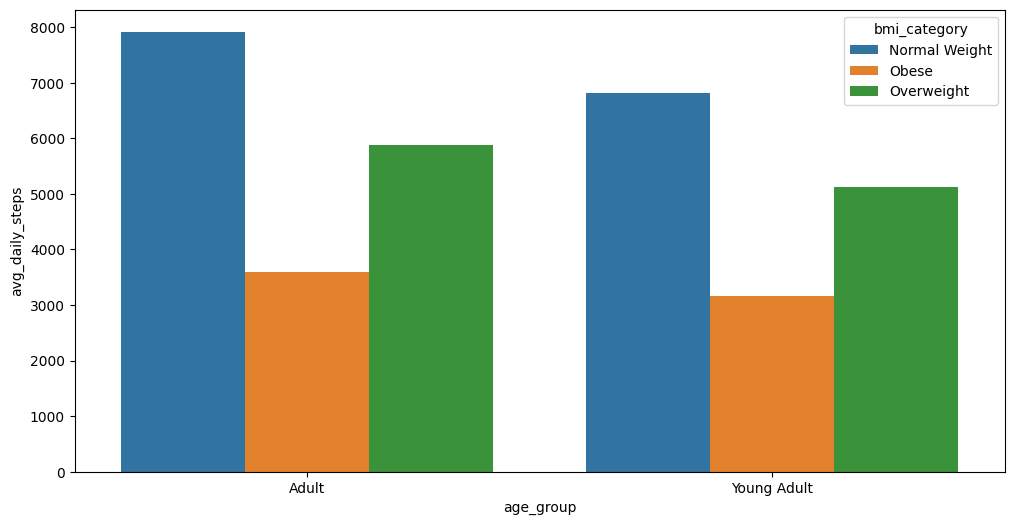

In [131]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_2, x='age_group', y='avg_daily_steps', hue='bmi_category')

plt.show()

In [132]:
df_sleep_health_lifestyle_male_3 = pd.read_sql(sql=text('SELECT * FROM high_bp_ratio_male'), con=engine)

df_sleep_health_lifestyle_male_3

,age_group,occupation,persons_high_bp_ratio,avg_stress_level
0,Adult,Doctor,4,4.0
1,Young Adult,Sales Representative,2,8.0
2,Young Adult,Teacher,1,7.0
3,Young Adult,Software Engineer,1,8.0


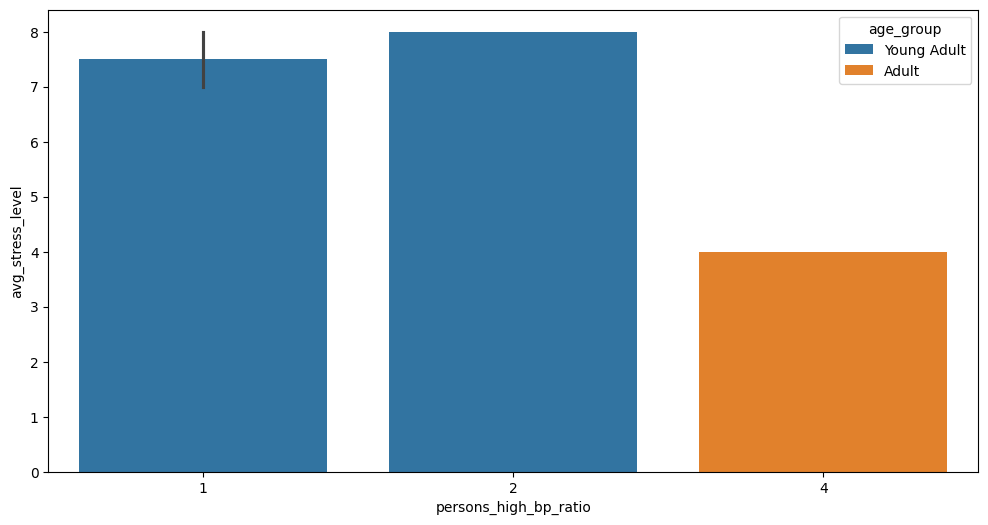

In [133]:
#Hier zeigt man den Stress Level mit hohem Blutdruck auf (gefiltert nach sys>=140 und dia>=90 in SQL ) -> hier würde ich gerne ncoh den Job aufzeigen
plt.figure(figsize=(12,6))
sns.barplot(data=df_sleep_health_lifestyle_male_3, x='persons_high_bp_ratio', y='avg_stress_level', hue='age_group')

plt.show()

In [134]:
df_sleep_health_lifestyle_male_4 = pd.read_sql(sql=text('SELECT * FROM sleep_health_lifestyle_male'), con=engine)
df_sleep_health_lifestyle_male_4


,gender,age_group,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps,sleep_disorder
0,Male,Young Adult,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,None
1,Male,Young Adult,28,Doctor,6.2,6,60,8,Normal Weight,125,80,75,10000,None
2,Male,Young Adult,28,Doctor,6.2,6,60,8,Normal Weight,125,80,75,10000,None
3,Male,Young Adult,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,Male,Young Adult,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,Male,Adult,44,Salesperson,6.5,6,45,7,Overweight,130,85,72,6000,None
185,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
186,Male,Adult,48,Doctor,7.3,7,65,5,Obese,142,92,83,3500,Insomnia
187,Male,Adult,49,Doctor,8.1,9,85,3,Obese,139,91,86,3700,Sleep Apnea


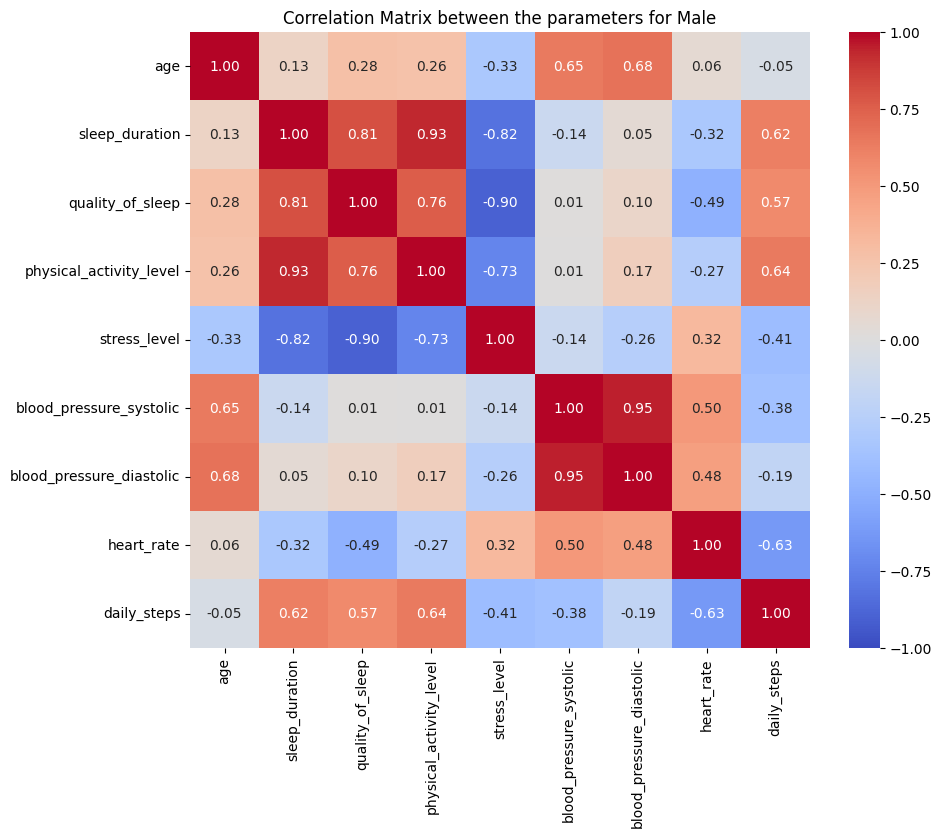

In [135]:
corr_matrix = df_sleep_health_lifestyle_male_4[['age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'heart_rate', 'daily_steps']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix between the parameters for Male')
plt.show()


In [153]:
df_sleep_health_lifestyle_male_5 = pd.read_sql(sql=text('SELECT * FROM sleep_quality_male'), con=engine)

In [154]:
df_sleep_health_lifestyle_male_5

,age,age_group,occupation,physical_activity_level,quality_of_sleep,sleep_duration,sleep_disorder,avg_stress_level
0,41,Adult,Lawyer,90,8,7.7,None,5.0
1,43,Adult,Engineer,90,8,7.8,Insomnia,5.0
2,44,Adult,Salesperson,45,6,6.4,Insomnia,7.0
3,44,Adult,Salesperson,45,6,6.3,Insomnia,7.0
4,41,Adult,Lawyer,90,8,7.6,Insomnia,5.0
...,...,...,...,...,...,...,...,...
62,31,Young Adult,Doctor,75,7,7.7,Sleep Apnea,6.0
63,30,Young Adult,Doctor,75,7,7.9,None,6.0
64,28,Young Adult,Software Engineer,30,4,5.9,Insomnia,8.0
65,27,Young Adult,Software Engineer,42,6,6.1,None,6.0


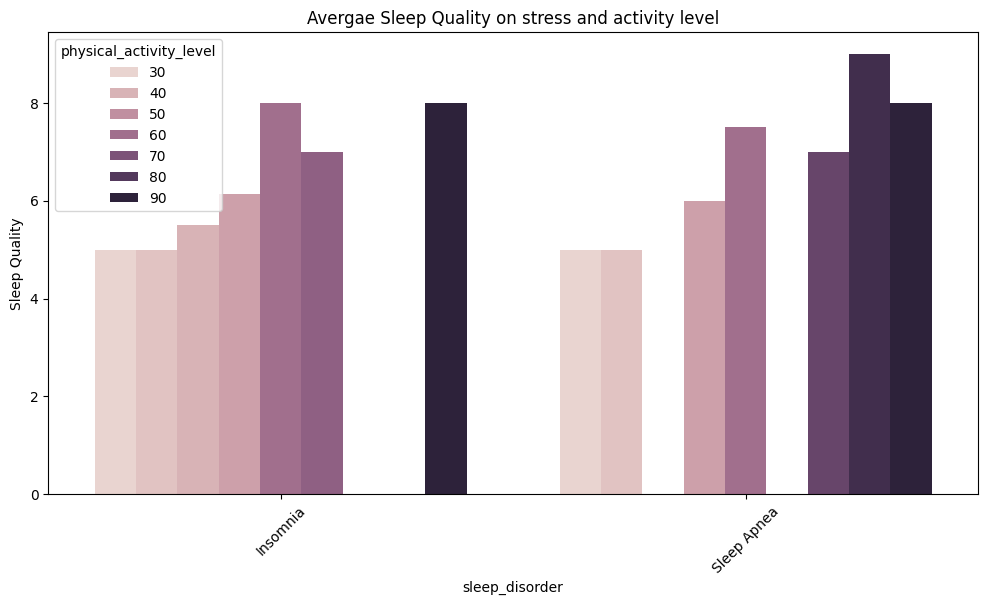

In [155]:
grouped = df_sleep_health_lifestyle_male_5.groupby(['sleep_disorder', 'physical_activity_level'])['quality_of_sleep'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='sleep_disorder', y='quality_of_sleep', hue='physical_activity_level')
plt.title('Avergae Sleep Quality on stress and activity level')
plt.ylabel('Sleep Quality')
plt.xticks(rotation=45)
plt.show()



In [ ]:
#Das könnten wir in kombinierter Weise anschauen...
df_sleep_health_lifestyle_male_5.groupby('sleep_disorder')['occupation'].value_counts()

sleep_disorder  occupation          
Insomnia        Salesperson             6
                Engineer                3
                Doctor                  2
                Lawyer                  2
                Teacher                 2
                Software Engineer       1
Sleep Apnea     Doctor                  3
                Lawyer                  2
                Engineer                1
                Sales Representative    1
                Salesperson             1
                Teacher                 1
Name: count, dtype: int64

In [159]:
df_sleep_health_lifestyle_male_5.groupby('sleep_disorder')['age_group'].value_counts()

sleep_disorder  age_group  
Insomnia        Adult          13
                Young Adult     3
Sleep Apnea     Adult           5
                Young Adult     4
Name: count, dtype: int64

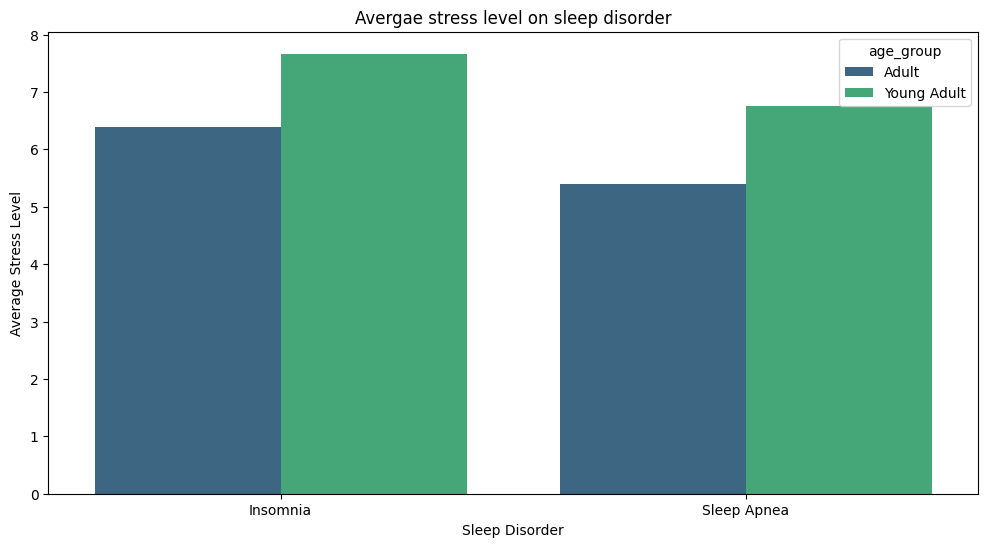

In [ ]:
grouped = df_sleep_health_lifestyle_male_5.groupby(['sleep_disorder', 'age_group'])['avg_stress_level'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='sleep_disorder', y='avg_stress_level', hue='age_group', palette='viridis')
plt.title('Avergae stress level on sleep disorder')
plt.ylabel('Average Stress Level')
plt.xlabel('Sleep Disorder')
#plt.xticks(rotation=45)
plt.show()

# gibt es Unterschiede im Stress Level zwischen Altersgruppen bei gleicher Schlafstörung?
# Haben Männer mit Insomnie einen höheeren durchschnittlichen Stress Level als Männer ohne Schlafstörung?

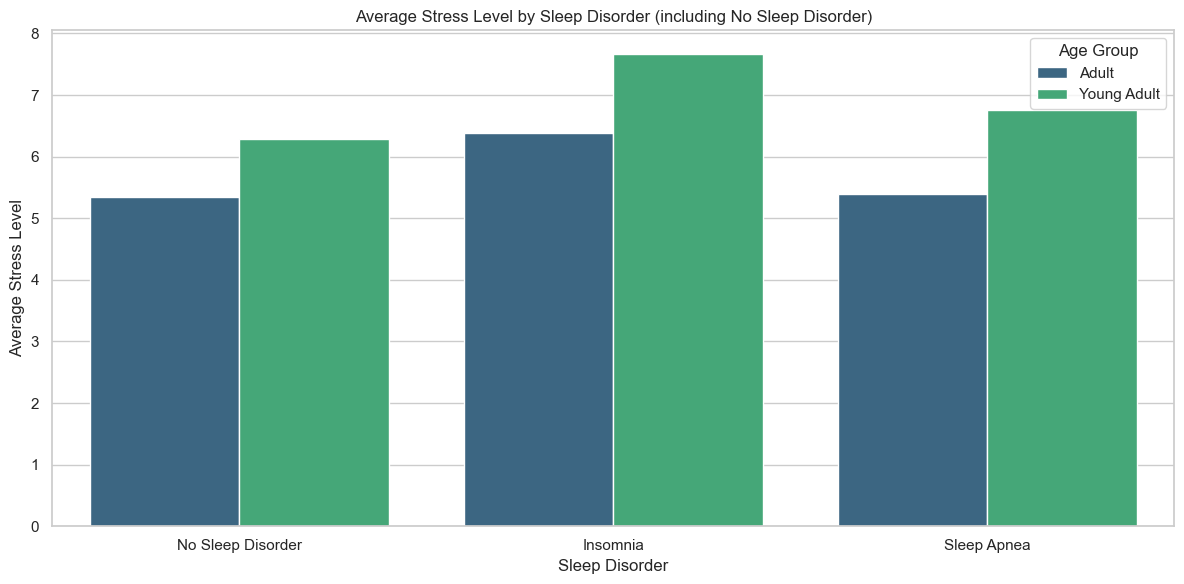

In [178]:
# Schritt 1: NaN-Werte in 'sleep_disorder' ersetzen
df_plot = df_sleep_health_lifestyle_male_5.copy()
df_plot['sleep_disorder'] = df_plot['sleep_disorder'].fillna('No Sleep Disorder')  # oder z.B. 'No Info'

order = ['No Sleep Disorder', 'Insomnia', 'Sleep Apnea']

# Schritt 2: Gruppieren
grouped = df_plot.groupby(['sleep_disorder', 'age_group'])['avg_stress_level'].mean().reset_index()

# Schritt 3: Plotten
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='sleep_disorder',
    y='avg_stress_level',
    hue='age_group',
    palette='viridis',
    order=order
)

plt.title('Average Stress Level by Sleep Disorder (including No Sleep Disorder)')
plt.ylabel('Average Stress Level')
plt.xlabel('Sleep Disorder')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


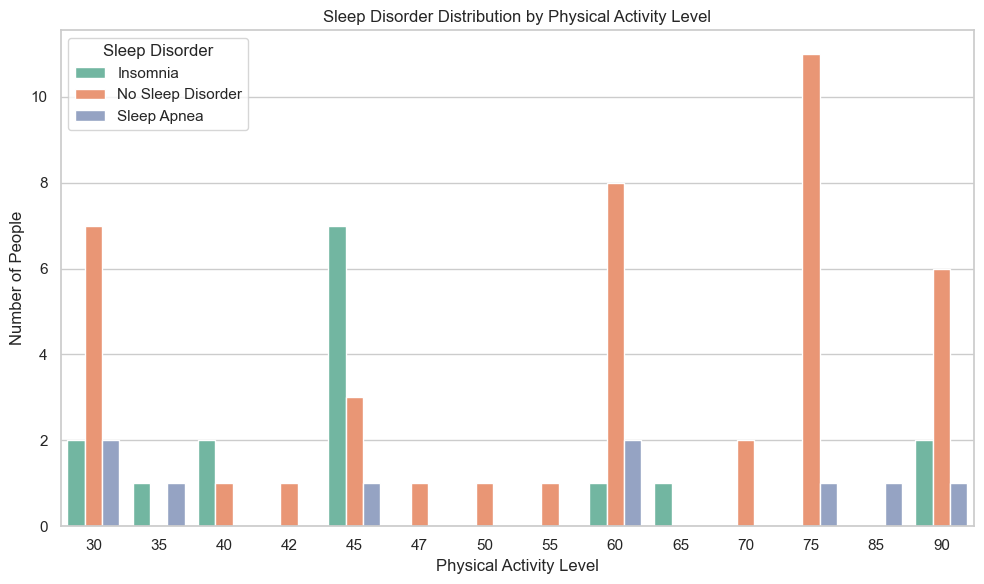

In [186]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# NaN-Werte in sleep_disorder behandeln
df_plot = df_sleep_health_lifestyle_male_5.copy()
df_plot['sleep_disorder'] = df_plot['sleep_disorder'].fillna('No Sleep Disorder')

# Gruppieren: Anzahl Personen je Kombination
grouped = df_plot.groupby(['physical_activity_level', 'sleep_disorder']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped,
    x='physical_activity_level',
    y='count',
    hue='sleep_disorder',
    palette='Set2'
)
plt.title('Sleep Disorder Distribution by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Number of People')
plt.legend(title='Sleep Disorder')
plt.tight_layout()
plt.show()


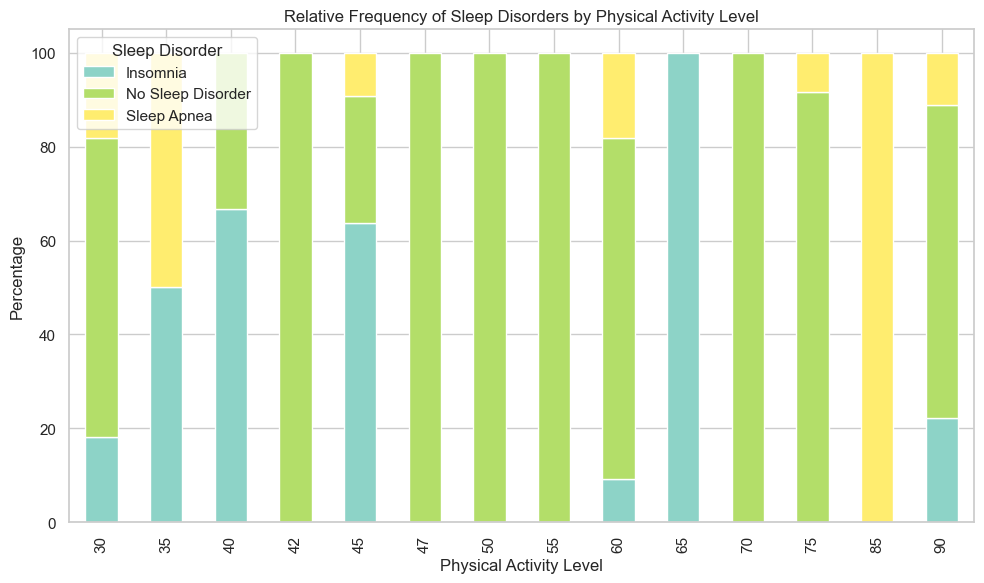

In [187]:
# Crosstab: Prozentual je Aktivitätslevel
crosstab = pd.crosstab(df_plot['physical_activity_level'], df_plot['sleep_disorder'], normalize='index') * 100

# Plot
crosstab.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set3')
plt.title('Relative Frequency of Sleep Disorders by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Percentage')
plt.legend(title='Sleep Disorder')
plt.tight_layout()
plt.show()


In [ ]:
#mit dem gesamten Datensatz: Wie unterscheiden sich Schlafstörungen nach Beruf?

In [ ]:
#Hypothese 1: Höherer Stress -> schlechtere Schlafqualität und kürzere Schlafdauer

#Hypothese 2:  Ältere Menschen schlafen kürzer, aber berichten bessere Qualität

<Axes: xlabel='age_group', ylabel='sleep_duration'>

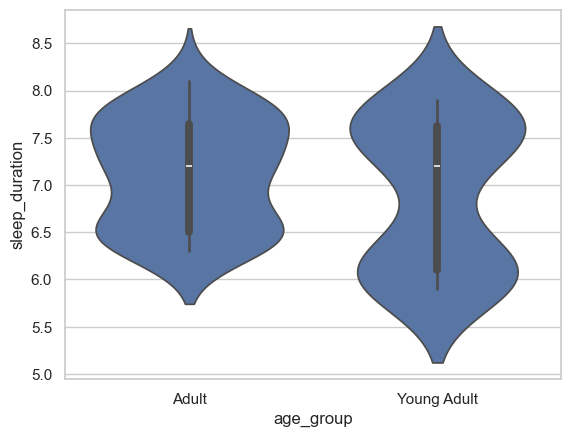

In [184]:
#sns.violinplot(data=df_sleep_health_lifestyle_male_5, x='age_group', y='sleep_duration', inner='quartile', palette='muted')
sns.violinplot(data=df_sleep_health_lifestyle_male_5, x='age_group', y='sleep_duration')


<Axes: xlabel='occupation'>

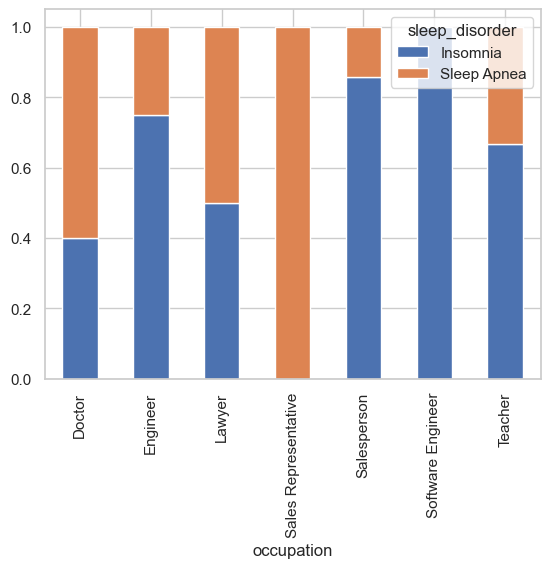

In [ ]:
#only male -> in this case: combined - female and male to be considered
pd.crosstab(df_sleep_health_lifestyle_male_5['occupation'], df_sleep_health_lifestyle_male_5['sleep_disorder'], normalize='index').plot(kind='bar', stacked=True)

<Axes: xlabel='sleep_disorder', ylabel='avg_stress_level'>

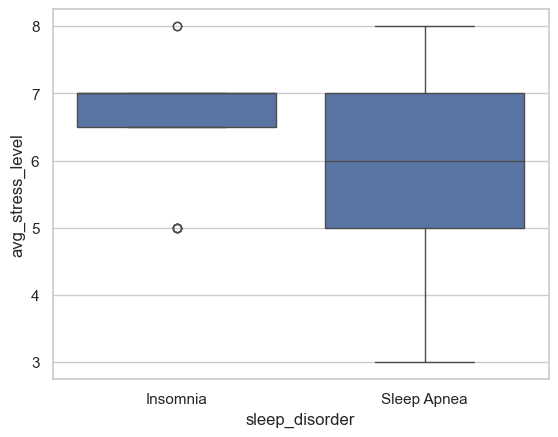

In [181]:
sns.boxplot(data=df_sleep_health_lifestyle_male_5, x='sleep_disorder', y='avg_stress_level')